# Credit Card Fraud Detection

This project predicts fraudulent transactions using the Credit Card Fraud dataset from Kaggle (Machine Learning Group ULB).
The goal is to build accurate models that can identify rare fraudulent activities while handling extreme class imbalance.

**Dataset:** 284,807 transactions, 492 frauds (0.17%)
**Techniques:** Data preprocessing, SMOTE oversampling, Logistic Regression, Random Forest, XGBoost, evaluation via Precision-Recall metrics.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_recall_curve, average_precision_score,
                             roc_auc_score)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


In [2]:
df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
df.head()


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()
print("\nMissing values:", df.isnull().sum().sum())
print("\nFraud ratio:", round(df["Class"].mean()*100, 3), "%")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

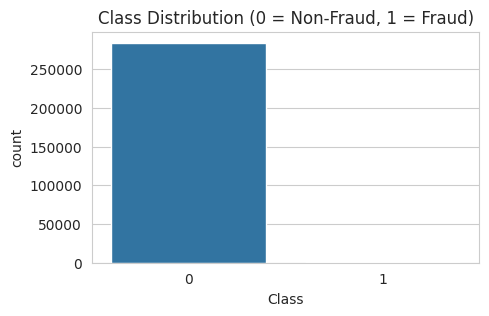

In [4]:
plt.figure(figsize=(5,3))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = Non-Fraud, 1 = Fraud)")
plt.show()


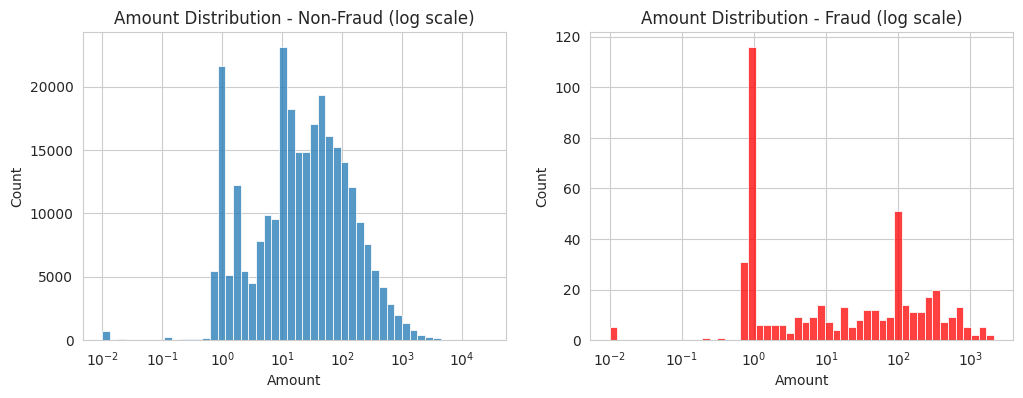

In [5]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df[df["Class"]==0]["Amount"], bins=50, log_scale=True)
plt.title("Amount Distribution - Non-Fraud (log scale)")

plt.subplot(1,2,2)
sns.histplot(df[df["Class"]==1]["Amount"], bins=50, color="r", log_scale=True)
plt.title("Amount Distribution - Fraud (log scale)")
plt.show()


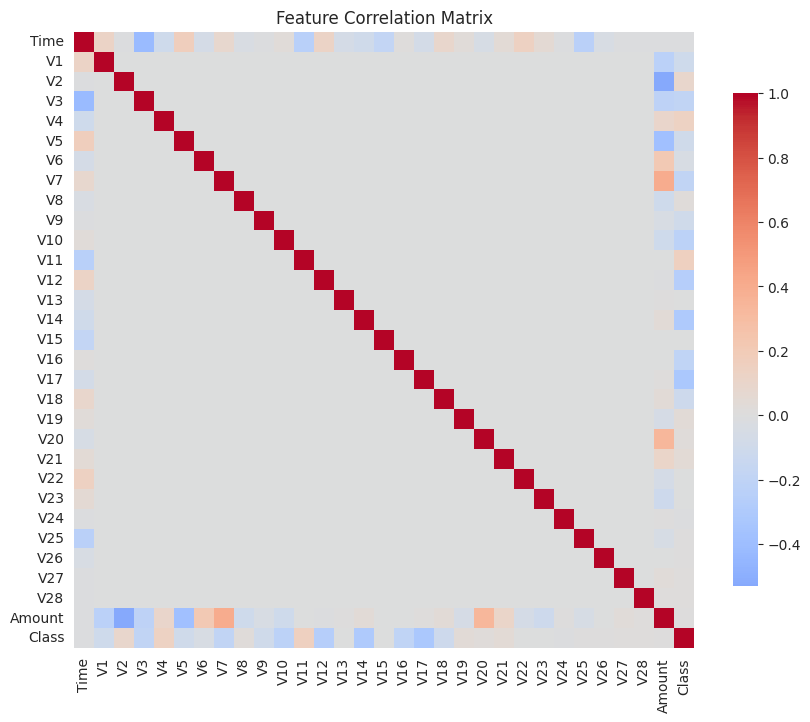

In [6]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={'shrink':.8})
plt.title("Feature Correlation Matrix")
plt.show()


In [7]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (227845, 30)
Testing shape: (56962, 30)


In [8]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[["Time","Amount"]] = scaler.fit_transform(X_train[["Time","Amount"]])
X_test_scaled[["Time","Amount"]] = scaler.transform(X_test[["Time","Amount"]])


In [9]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print("Baseline Logistic Regression")
print(classification_report(y_test, y_pred_lr, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))
print("Average Precision (PR AUC):", average_precision_score(y_test, y_prob_lr))


Baseline Logistic Regression
              precision    recall  f1-score   support

           0     0.9994    0.9998    0.9996     56864
           1     0.8289    0.6429    0.7241        98

    accuracy                         0.9992     56962
   macro avg     0.9142    0.8213    0.8619     56962
weighted avg     0.9991    0.9992    0.9991     56962

ROC AUC: 0.9558983554029378
Average Precision (PR AUC): 0.7431691767832421


In [10]:
smote = SMOTE(random_state=42, sampling_strategy=0.1)
pipeline = ImbPipeline([
    ('smote', smote),
    ('clf', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train_scaled, y_train)
y_pred_sm = pipeline.predict(X_test_scaled)
y_prob_sm = pipeline.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression with SMOTE")
print(classification_report(y_test, y_pred_sm, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_prob_sm))
print("Average Precision (PR AUC):", average_precision_score(y_test, y_prob_sm))


Logistic Regression with SMOTE
              precision    recall  f1-score   support

           0     0.9998    0.9973    0.9986     56864
           1     0.3640    0.8878    0.5163        98

    accuracy                         0.9971     56962
   macro avg     0.6819    0.9425    0.7574     56962
weighted avg     0.9987    0.9971    0.9977     56962

ROC AUC: 0.9661600395645034
Average Precision (PR AUC): 0.7501169458492893


In [11]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf, digits=4))
print("PR AUC:", average_precision_score(y_test, y_prob_rf))

# XGBoost
scale = (len(y_train) - y_train.sum()) / y_train.sum()
xgb = XGBClassifier(n_estimators=200, scale_pos_weight=scale, eval_metric='logloss', use_label_encoder=False, random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:,1]

print("\nXGBoost")
print(classification_report(y_test, y_pred_xgb, digits=4))
print("PR AUC:", average_precision_score(y_test, y_prob_xgb))


Random Forest
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9610    0.7551    0.8457        98

    accuracy                         0.9995     56962
   macro avg     0.9803    0.8775    0.9227     56962
weighted avg     0.9995    0.9995    0.9995     56962

PR AUC: 0.8589278575500874

XGBoost
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9998     56864
           1     0.8817    0.8367    0.8586        98

    accuracy                         0.9995     56962
   macro avg     0.9407    0.9183    0.9292     56962
weighted avg     0.9995    0.9995    0.9995     56962

PR AUC: 0.880381640438991


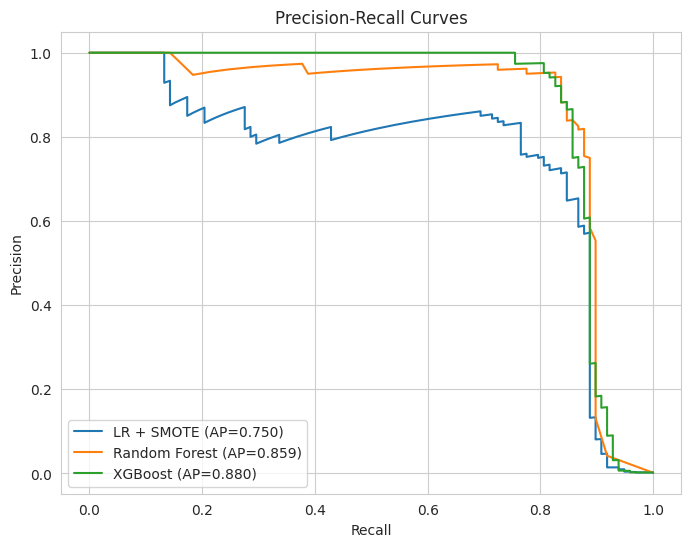

In [12]:
plt.figure(figsize=(8,6))
for name, prob in [("LR + SMOTE", y_prob_sm), ("Random Forest", y_prob_rf), ("XGBoost", y_prob_xgb)]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()


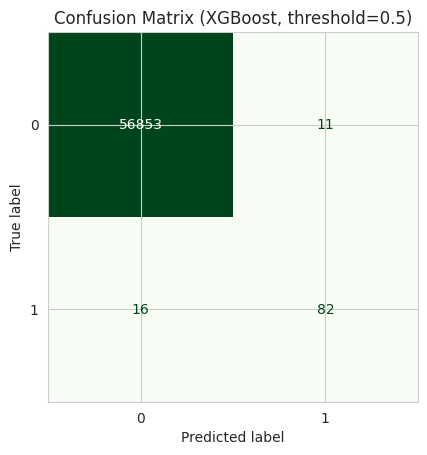

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

best_probs = y_prob_xgb
best_preds = (best_probs >= 0.5).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, best_preds, cmap="Greens", colorbar=False)
plt.title("Confusion Matrix (XGBoost, threshold=0.5)")
plt.show()


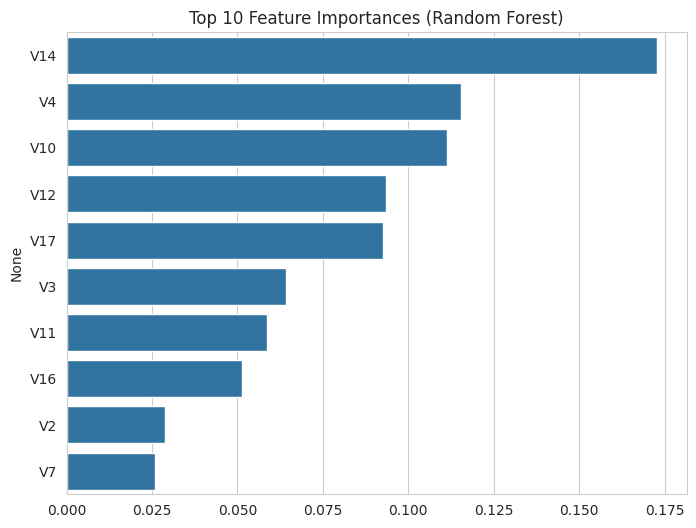

In [14]:
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10])
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()


In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X_train_scaled, y_train, cv=skf, scoring='average_precision', n_jobs=-1)

print("Cross-Validation Average Precision Scores:", cv_scores)
print("Mean CV AP:", round(cv_scores.mean(), 4))


Cross-Validation Average Precision Scores: [0.86236283 0.82796101 0.84277104 0.87982992 0.86375246]
Mean CV AP: 0.8553


In [16]:
import joblib
joblib.dump(xgb, "fraud_xgb_model.pkl")
print("Model saved as fraud_xgb_model.pkl")


Model saved as fraud_xgb_model.pkl


## Conclusion

This project demonstrates how machine learning can be applied to detect fraudulent credit card transactions in a highly imbalanced dataset.

- The dataset contained only 0.17% fraudulent cases.
- Precision–Recall AUC was used as the main evaluation metric.
- SMOTE improved recall significantly for Logistic Regression.
- Random Forest and XGBoost performed best, achieving strong precision–recall tradeoffs.

Future work:
- Apply anomaly detection or deep learning models (Autoencoders, Isolation Forest).
- Implement time-aware validation to reflect real-world deployment.
- Deploy the trained model as an API or Streamlit dashboard for demonstration.
